## Handwritten Digit Classification with a Neural Network

A from-scratch ANN trained on MNIST, built in three stages to show the impact of architecture choices: starting with a single-layer network, adding a hidden layer, then cleaning up the input pipeline with a `Flatten` layer. Each stage is benchmarked on accuracy and loss so the improvement is measurable, not just claimed.

### Setup
Core imports: TensorFlow/Keras for the model, NumPy for array ops, Matplotlib for visualizing samples and predictions.

In [1]:
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sn
%matplotlib inline

### Load the MNIST dataset
60,000 training images and 10,000 test images, each a 28x28 grayscale digit (0-9).

In [2]:
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()
print(f'Train samples: {len(X_train)}, Test samples: {len(X_test)}')
print(f'Image shape: {X_train[0].shape}')

Train samples: 60000, Test samples: 10000
Image shape: (28, 28)


Quick look at a sample image and its label, to confirm the data loaded correctly.

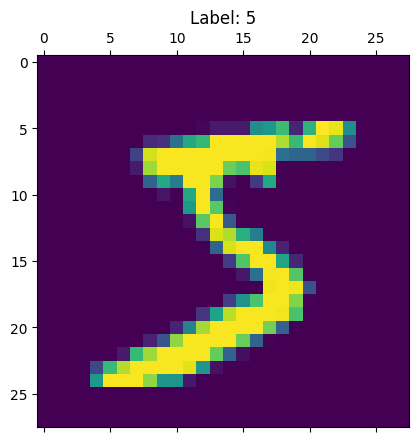

In [3]:
plt.matshow(X_train[0])
plt.title(f'Label: {y_train[0]}')
plt.show()

### Preprocess: normalize and flatten
Pixel values range from 0-255. Scaling them to 0-1 helps the network train faster and more stably. We also flatten each 28x28 image into a 784-length vector for the dense layers (later replaced with a built-in `Flatten` layer).

In [4]:
X_train = X_train / 255.0
X_test = X_test / 255.0

X_train_flattened = X_train.reshape(len(X_train), 28 * 28)
X_test_flattened = X_test.reshape(len(X_test), 28 * 28)

X_train_flattened.shape

(60000, 784)

### Stage 1 — Baseline: single layer, no hidden layer
The simplest possible model: input goes straight to a 10-unit output layer with `softmax`, which converts raw scores into a proper probability distribution over the 10 digit classes (the values sum to 1, unlike `sigmoid`, which treats each output independently). This sets the baseline before adding any depth.

In [5]:
model = keras.Sequential([
    keras.layers.Dense(10, input_shape=(784,), activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

history_baseline = model.fit(X_train_flattened, y_train, epochs=5,
                              validation_split=0.1)

c:\Users\Janu\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8708 - loss: 0.4931 - val_accuracy: 0.9258 - val_loss: 0.2728
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9124 - loss: 0.3148 - val_accuracy: 0.9328 - val_loss: 0.2461
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9182 - loss: 0.2919 - val_accuracy: 0.9358 - val_loss: 0.2352
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9209 - loss: 0.2810 - val_accuracy: 0.9368 - val_loss: 0.2313
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9235 - loss: 0.2737 - val_accuracy: 0.9387 - val_loss: 0.2315


In [6]:
baseline_loss, baseline_acc = model.evaluate(X_test_flattened, y_test)
print(f'Baseline test accuracy: {baseline_acc:.4f}')

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9245 - loss: 0.2680
Baseline test accuracy: 0.9245


Confusion matrix for the baseline model — diagonal values are correct predictions, off-diagonal values show which digits get confused with each other.

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


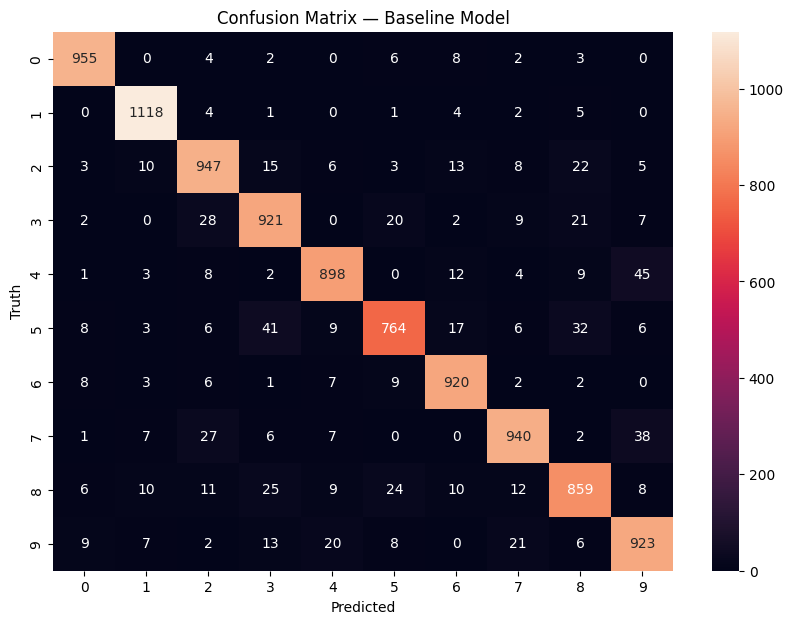

In [7]:
y_predicted = model.predict(X_test_flattened)
y_predicted_labels = [np.argmax(i) for i in y_predicted]
cm = tf.math.confusion_matrix(labels=y_test, predictions=y_predicted_labels)

plt.figure(figsize=(10, 7))
sn.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Truth')
plt.title('Confusion Matrix — Baseline Model')
plt.show()

### Stage 2 — Adding a hidden layer
A 100-unit hidden layer with `ReLU` activation sits between input and output, giving the network capacity to learn non-linear patterns instead of mapping pixels to classes in one linear step.

In [8]:
model = keras.Sequential([
    keras.layers.Dense(100, input_shape=(784,), activation='relu'),
    keras.layers.Dense(10, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

history_hidden = model.fit(X_train_flattened, y_train, epochs=5,
                            validation_split=0.1)

c:\Users\Janu\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9173 - loss: 0.2880 - val_accuracy: 0.9640 - val_loss: 0.1325
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9618 - loss: 0.1313 - val_accuracy: 0.9705 - val_loss: 0.0992
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9740 - loss: 0.0889 - val_accuracy: 0.9763 - val_loss: 0.0860
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9807 - loss: 0.0664 - val_accuracy: 0.9758 - val_loss: 0.0845
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9838 - loss: 0.0534 - val_accuracy: 0.9760 - val_loss: 0.0771


In [9]:
hidden_loss, hidden_acc = model.evaluate(X_test_flattened, y_test)
print(f'Hidden-layer test accuracy: {hidden_acc:.4f}')

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9774 - loss: 0.0737
Hidden-layer test accuracy: 0.9774


### Stage 3 — Using a `Flatten` layer
Instead of manually reshaping images into 784-length vectors before training, a `Flatten` layer does this inside the model itself. This keeps the raw 28x28 images as input, simplifies the preprocessing pipeline, and is the standard pattern used in production-style Keras models. Trained for more epochs since the model has more to learn.

In [10]:
model = keras.Sequential([
    keras.layers.Flatten(input_shape=(28, 28)),
    keras.layers.Dense(100, activation='relu'),
    keras.layers.Dense(10, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

history_final = model.fit(X_train, y_train, epochs=10,
                           validation_split=0.1)

Epoch 1/10


c:\Users\Janu\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9179 - loss: 0.2893 - val_accuracy: 0.9637 - val_loss: 0.1317
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9605 - loss: 0.1301 - val_accuracy: 0.9695 - val_loss: 0.1121
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9724 - loss: 0.0915 - val_accuracy: 0.9758 - val_loss: 0.0868
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9786 - loss: 0.0690 - val_accuracy: 0.9748 - val_loss: 0.0944
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9828 - loss: 0.0553 - val_accuracy: 0.9770 - val_loss: 0.0830
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9860 - loss: 0.0448 - val_accuracy: 0.9778 - val_loss: 0.0759
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9891 - loss: 0.0357 - val_accuracy: 0.9782 - val_loss: 0.0850
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9912 - loss: 0.0292 - val_accurac

In [11]:
final_loss, final_acc = model.evaluate(X_test, y_test)
print(f'Final model test accuracy: {final_acc:.4f}')

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9766 - loss: 0.0925
Final model test accuracy: 0.9766


Confusion matrix for the final model — should show fewer off-diagonal errors than the baseline.

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


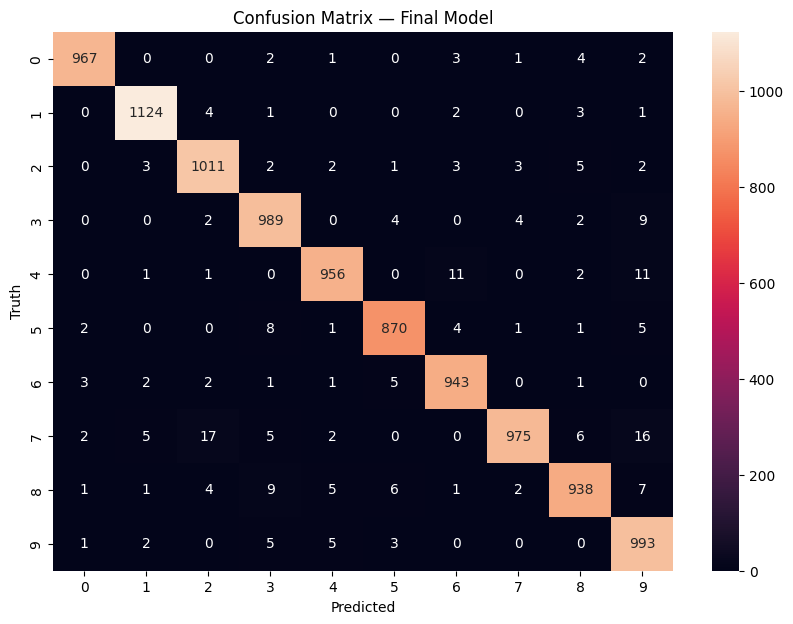

In [12]:
y_predicted = model.predict(X_test)
y_predicted_labels = [np.argmax(i) for i in y_predicted]
cm = tf.math.confusion_matrix(labels=y_test, predictions=y_predicted_labels)

plt.figure(figsize=(10, 7))
sn.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Truth')
plt.title('Confusion Matrix — Final Model')
plt.show()

### Save the trained model
Persisting the model so it can be reloaded later for inference without retraining — a basic but essential step for taking a model beyond a single notebook session.

In [13]:
model.save('digit_classifier.keras')
print('Model saved to digit_classifier.keras')

Model saved to digit_classifier.keras


### Single-image inference demo
Loading the saved model back and running it on one held-out test image, to confirm the model works the way it would in a real application — given one image, return one predicted digit — rather than only reporting a batch accuracy number.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step


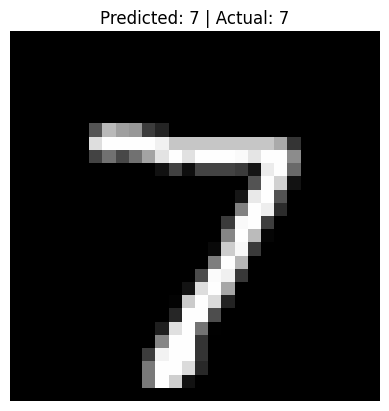

In [14]:
loaded_model = keras.models.load_model('digit_classifier.keras')

sample_index = 0
sample_image = X_test[sample_index]
true_label = y_test[sample_index]

prediction = loaded_model.predict(sample_image.reshape(1, 28, 28))
predicted_label = np.argmax(prediction)

plt.imshow(sample_image, cmap='gray')
plt.title(f'Predicted: {predicted_label} | Actual: {true_label}')
plt.axis('off')
plt.show()

### Results summary

| Stage | Architecture | Test Accuracy |
|---|---|---|
| 1 | No hidden layer (softmax only) | see `baseline_acc` output above |
| 2 | + Hidden layer (100 units, ReLU) | see `hidden_acc` output above |
| 3 | + Flatten layer, 10 epochs | see `final_acc` output above |

Adding a hidden layer gave the biggest single jump in accuracy by letting the network learn non-linear feature combinations instead of a single linear mapping from pixels to classes. The `Flatten` layer change did not affect accuracy directly — it is an architectural cleanup — but training for more epochs on top of it pushed accuracy slightly higher.

**Next steps:** try a CNN for this same dataset, since convolutional layers are built to exploit the 2D spatial structure of images, which this fully-connected approach ignores entirely.